# Lab 34 — The Telegraph as a Communication System: Morse Keying, Codes, Cables and Repeaters

**Companion to Chapter 1** (*The Story of Telecommunication*).
**Time needed:** about 75 minutes. **Difficulty:** introductory.

The electric telegraph of the 1840s already posed every question this book answers. How should symbols be represented, and how
long should each take? (Morse's dots and dashes are a variable-length source code, eighty years before Huffman.) How fast can a
line be keyed before its pulses smear into each other? (Kelvin's law of squares for the Atlantic cable is the first theory of
intersymbol interference.) What happens when a weak signal is relayed many times? (The answer, regenerate rather than amplify, is
why everything became digital.) This lab replays those questions with the same models that drew Chapter 1's figures, and lets you
change the history: a longer cable, a different language, more repeaters.

### What you will learn
1. Generate a Morse-keyed carrier with ITU timing and see why hard keying "clicks" while shaped keying does not.
2. Measure Morse code against entropy, a Huffman code and Shannon's capacity of the telegraph channel, on any text.
3. Model the Atlantic cable as a distributed RC line and find how fast it could be keyed (the law of squares).
4. Compare a chain of analog repeaters with a chain of digital regenerators, and see why digital won.
5. Put numbers on the semaphore telegraph and the capacity of a telephone line.

### Prerequisites
None beyond Chapter 1; this is the gentlest lab and a good first one. Python and NumPy basics.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Morse keying and key clicks | yes |
| 2 | Morse versus Huffman, entropy and capacity | yes |
| 3 | The Atlantic cable: RC diffusion and the law of squares | yes |
| 4 | Analog repeaters versus regenerators | yes |
| 5 | Semaphores and telephone lines: rates and capacity | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.optimize import brentq
import commlib as cl
from commlib import infotheory as it
from commlib import labkit as lk

rng = lk.setup(seed=34, lab="34")
MORSE = {'A': '.-', 'B': '-...', 'C': '-.-.', 'D': '-..', 'E': '.', 'F': '..-.', 'G': '--.', 'H': '....', 'I': '..', 'J': '.---',
         'K': '-.-', 'L': '.-..', 'M': '--', 'N': '-.', 'O': '---', 'P': '.--.', 'Q': '--.-', 'R': '.-.', 'S': '...', 'T': '-',
         'U': '..-', 'V': '...-', 'W': '.--', 'X': '-..-', 'Y': '-.--', 'Z': '--..'}
ENGLISH = {'E': 12.70, 'T': 9.06, 'A': 8.17, 'O': 7.51, 'I': 6.97, 'N': 6.75, 'S': 6.33, 'H': 6.09, 'R': 5.99, 'D': 4.25, 'L': 4.03,
           'C': 2.78, 'U': 2.76, 'M': 2.41, 'W': 2.36, 'F': 2.23, 'G': 2.02, 'Y': 1.97, 'P': 1.93, 'B': 1.29, 'V': 0.98, 'K': 0.77,
           'J': 0.15, 'X': 0.15, 'Q': 0.10, 'Z': 0.07}       # approximate % of letters in English text (standard tables)
Qf = lambda x: 0.5 * erfc(np.asarray(x) / np.sqrt(2))


def keyed_envelope(text, fs=200):
    """On/off envelope with ITU timing: dot 1 unit, dash 3, element gap 1, letter gap 3, word gap 7 (fs samples per unit)."""
    seq = []
    for word in text.upper().split():
        for ch in word:
            if ch not in MORSE:
                continue
            for sym in MORSE[ch]:
                seq += [1] * (1 if sym == "." else 3) + [0]
            seq += [0, 0]
        seq += [0] * 4
    return np.repeat(np.array(seq, float), fs)


def morse_units(code):
    """Duration of a letter in dot units including the 3-unit letter gap."""
    return sum(1 if c == "." else 3 for c in code) + (len(code) - 1) + 3

Lab 34 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 34


## 1. Morse keying and key clicks

International Morse timing: a dot is one unit, a dash three, the gap inside a letter one, between letters three and between words
seven. At $w$ words per minute the unit is $1.2/w$ seconds (the standard word PARIS is 50 units). Keying a carrier on and off with
square edges is amplitude modulation by a rectangular pulse train: its spectrum falls only as $1/f^2$ in power, so a hard-keyed
transmitter splatters "key clicks" into neighbouring channels. Shaping the edges (a raised-cosine rise over a fraction of a unit)
makes the spectrum fall far faster, the first lesson in pulse shaping (Chapter 8).

### Interactive: message, speed and edge shaping

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

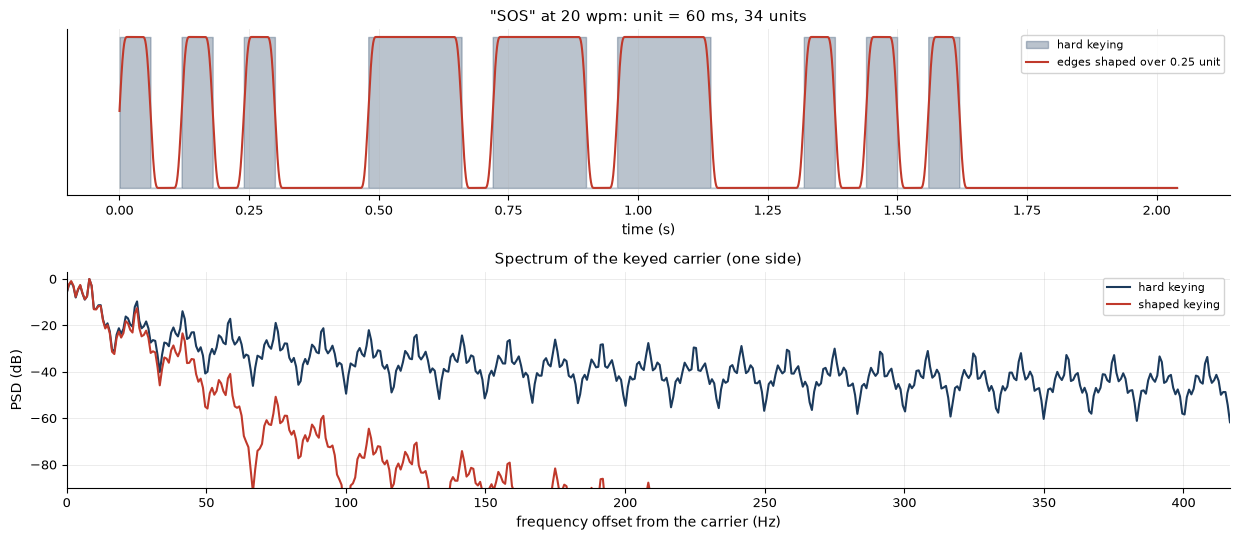

,
dot unit at this speed,60 ms
message duration,2.04 s
units in the word PARIS (with word gap),50


In [3]:
def keying_demo(text="SOS", wpm=20, edge=0.25):
    fs = 200
    env = keyed_envelope(text, fs)
    unit = 1.2 / wpm
    L = max(1, int(edge * fs))
    w = np.hanning(2 * L + 1); w /= w.sum()
    soft = np.convolve(env, w, mode="same")
    long = np.tile(keyed_envelope("PARIS PARIS", fs), 4)
    softl = np.convolve(long, w, mode="same")
    fig, ax = lk.fig((12.5, 5.5), 2, 1, gridspec_kw=dict(height_ratios=[1, 1.3]))
    t = np.arange(len(env)) / fs * unit
    ax[0].fill_between(t, env, step="pre", color=lk.NAVY, alpha=0.3, label="hard keying"); ax[0].plot(t, soft, color=lk.RED, label=f"edges shaped over {edge:g} unit")
    ax[0].set_xlabel("time (s)"); ax[0].set_yticks([]); ax[0].legend(fontsize=8, loc="upper right")
    ax[0].set_title(f"\"{text.upper()}\" at {wpm} wpm: unit = {unit * 1e3:.0f} ms, {len(env) // fs} units")
    for sig, col, lab in [(long, lk.NAVY, "hard keying"), (softl, lk.RED, "shaped keying")]:
        f, p = cl.welch_psd(sig - sig.mean(), fs, 4096)
        ax[1].plot(f[f >= 0] / unit, p[f >= 0] - p.max(), color=col, label=lab)
    ax[1].set_xlim(0, 25 / unit); ax[1].set_ylim(-90, 3); ax[1].set_xlabel("frequency offset from the carrier (Hz)"); ax[1].set_ylabel("PSD (dB)")
    ax[1].legend(fontsize=8); ax[1].set_title("Spectrum of the keyed carrier (one side)")
    lk.show(fig)
    lk.table([["dot unit at this speed", f"{unit * 1e3:.0f} ms"], ["message duration", f"{len(env) / fs * unit:.2f} s"],
              ["units in the word PARIS (with word gap)", len(keyed_envelope("PARIS", 1))]], ["", ""])

lk.interact(keying_demo, text=lk.choice(["SOS", "WHAT HATH GOD WROUGHT", "PARIS", "CQ CQ DE W1AW"], "SOS", "message"),
            wpm=lk.islider(20, 5, 40, 1, "words per minute"), edge=lk.slider(0.25, 0.02, 0.5, 0.01, "edge shaping (units)"))

**What you should see.** SOS as three dots, three dashes and three dots. With hard keying the spectrum's sidelobes fall slowly and are
still about 40–50 dB down twenty unit-rates away; shaping the edges over a quarter of a unit pushes them below −80 dB within a few
unit-rates, at no cost in readability. PARIS is 50 units, which is why words per minute converts to $1.2/w$ seconds per unit.

### Try it yourself 1.1
How long (ms) is a dot at 25 words per minute?

In [5]:
answer_1_1 = None
lk.check("1.1 dot length at 25 wpm (ms)", answer_1_1, 1200 / 25, atol=0.5)

[TODO] 1.1 dot length at 25 wpm (ms): not attempted yet: replace the None with your answer

## 2. Morse versus Huffman, entropy and capacity

Vail and Morse gave the commonest letters the shortest codes by counting the type in a printer's case: E is one dot, T one dash. That
is a variable-length source code. Chapter 1's worked example: with English letter frequencies the average Morse letter costs 9.07 units,
against an entropy of 4.17 bits and a Huffman code of 4.20 binary digits. But Morse units are not free binary digits: the line must be on
for 1 or 3 units, then off; Shannon computed the capacity of this constrained channel as about 0.539 bit per unit. So a Morse letter uses
$9.07 \times 0.539 = 4.89$ bits of capacity to carry 4.17 bits: about 85% efficient.

Shannon's model: dot 2 units (with its trailing space), dash 4, letter space 3, word space 6, and a space may not follow a space. The
capacity is $\log_2 W_0$ where $W_0$ is the largest root of the state equation of that grammar; we solve it below.

### Interactive: your own text

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

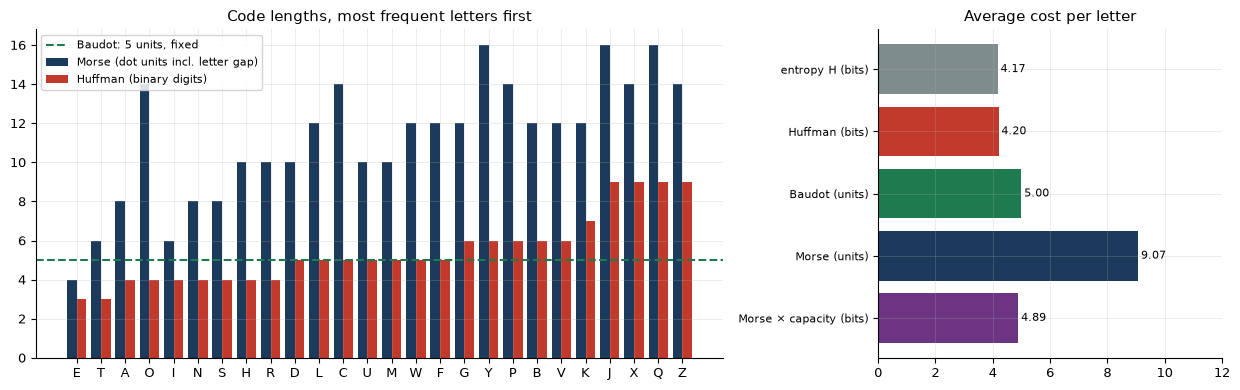

,
letter statistics from,standard English table
entropy H,4.17 bits/letter
Huffman average,4.20 binary digits/letter
Morse average,9.07 units/letter
Shannon capacity of the telegraph channel,0.539 bit/unit
Morse efficiency H / (avg × C),85%
your message (71 letters),"620 Morse units, 288 Huffman bits"


In [7]:
def shannon_telegraph_capacity():
    # states: after a mark (dot/dash) or after a space; from "mark": dot, dash -> mark; letter/word space -> space; from "space": dot, dash -> mark
    f = lambda W: -(W ** -2 + W ** -4 - 1) - (W ** -3 + W ** -6) * (W ** -2 + W ** -4)
    return np.log2(brentq(f, 1.01, 3.0))

C_TEL = shannon_telegraph_capacity()

def code_demo(text="WHAT HATH GOD WROUGHT, THE FIRST MESSAGE SENT OVER THE WASHINGTON TO BALTIMORE LINE IN 1844", use_text_stats=False):
    letters = [c for c in text.upper() if c in MORSE]
    cnt = Counter(letters)
    p = {k: v / sum(ENGLISH.values()) for k, v in ENGLISH.items()} if not use_text_stats else {k: cnt[k] / len(letters) for k in cnt}
    huff = it.huffman_code(p)
    H = -sum(q * np.log2(q) for q in p.values() if q > 0)
    avg_m = sum(p[k] * morse_units(MORSE[k]) for k in p)
    avg_h = sum(p[k] * len(huff[k]) for k in p)
    order = sorted(p, key=lambda k: -p[k])
    fig, ax = lk.fig((12.5, 4), 1, 2, gridspec_kw=dict(width_ratios=[2, 1]))
    x = np.arange(len(order))
    ax[0].bar(x - 0.2, [morse_units(MORSE[k]) for k in order], 0.4, color=lk.NAVY, label="Morse (dot units incl. letter gap)")
    ax[0].bar(x + 0.2, [len(huff[k]) for k in order], 0.4, color=lk.RED, label="Huffman (binary digits)")
    ax[0].axhline(5, color=lk.GREEN, ls="--", label="Baudot: 5 units, fixed")
    ax[0].set_xticks(x); ax[0].set_xticklabels(order); ax[0].legend(fontsize=8); ax[0].set_title("Code lengths, most frequent letters first")
    vals = [H, avg_h, 5.0, avg_m, avg_m * C_TEL]
    names = ["entropy H (bits)", "Huffman (bits)", "Baudot (units)", "Morse (units)", "Morse × capacity (bits)"]
    ax[1].barh(np.arange(5)[::-1], vals, color=[lk.GRAY, lk.RED, lk.GREEN, lk.NAVY, lk.PURPLE])
    for i, v in enumerate(vals):
        ax[1].text(v + 0.1, 4 - i, f"{v:.2f}", va="center", fontsize=8)
    ax[1].set_yticks(np.arange(5)[::-1]); ax[1].set_yticklabels(names, fontsize=8); ax[1].set_xlim(0, 12); ax[1].set_title("Average cost per letter")
    lk.show(fig)
    msg_m = sum(morse_units(MORSE[c]) for c in letters)
    msg_h = sum(len(huff.get(c, "0" * 10)) for c in letters)
    lk.table([["letter statistics from", "your text" if use_text_stats else "standard English table"],
              ["entropy H", f"{H:.2f} bits/letter"], ["Huffman average", f"{avg_h:.2f} binary digits/letter"],
              ["Morse average", f"{avg_m:.2f} units/letter"], ["Shannon capacity of the telegraph channel", f"{C_TEL:.3f} bit/unit"],
              ["Morse efficiency H / (avg × C)", f"{100 * H / (avg_m * C_TEL):.0f}%"],
              [f"your message ({len(letters)} letters)", f"{msg_m} Morse units, {msg_h} Huffman bits"]], ["", ""])

lk.interact(code_demo, text=lk.choice(["WHAT HATH GOD WROUGHT, THE FIRST MESSAGE SENT OVER THE WASHINGTON TO BALTIMORE LINE IN 1844",
                                        "THE QUICK BROWN FOX JUMPS OVER THE LAZY DOG", "ZYZZYVA QUIZ JAZZ BUZZ"], None, "text"),
            use_text_stats=lk.choice([False, True], False, "use the text's own letter statistics"))

**What you should see.** Morse lengths rise roughly in step with Huffman's as letters get rarer. The table reproduces the chapter: entropy
4.17 bits, Huffman 4.20, Morse 9.07 units, Shannon's capacity 0.539 bit/unit and an efficiency of about 85%. Switch to the text's own
statistics on a strange text (ZYZZYVA…) and Morse, designed for English, becomes much less efficient while Huffman adapts.

### Try it yourself 2.1
How many dot units does the letter Q (– – · –) take, including the letter gap?

In [9]:
answer_2_1 = None
lk.check("2.1 Morse units of Q", answer_2_1, morse_units(MORSE["Q"]), atol=0)

[TODO] 2.1 Morse units of Q: not attempted yet: replace the None with your answer

## 3. The Atlantic cable: RC diffusion and the law of squares

A long submarine cable at telegraph speeds is a distributed resistance $R$ and capacitance $C$ per unit length (inductance negligible).
Kelvin (1855) showed that a voltage step diffuses along it: the far-end voltage is $\mathrm{erfc}\big(\ell/(2\sqrt{t/RC})\big)$, with a
time constant $\tau = RC\ell^2$ that grows as the **square** of the length. Chapter 1's worked example estimates $\tau \approx 2.8$ s for
the 1866 cable (2.1 Ω/km, 0.15 µF/km, 3000 km) and 6.5 s for 1858; requiring a 10% swing for reversals gives an element of
$0.24\tau$ and, at about 19 elements per word, about 4.6 and 2.0 words per minute. The 1866 cable worked at about eight in service.

### Interactive: cable length and keying speed

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

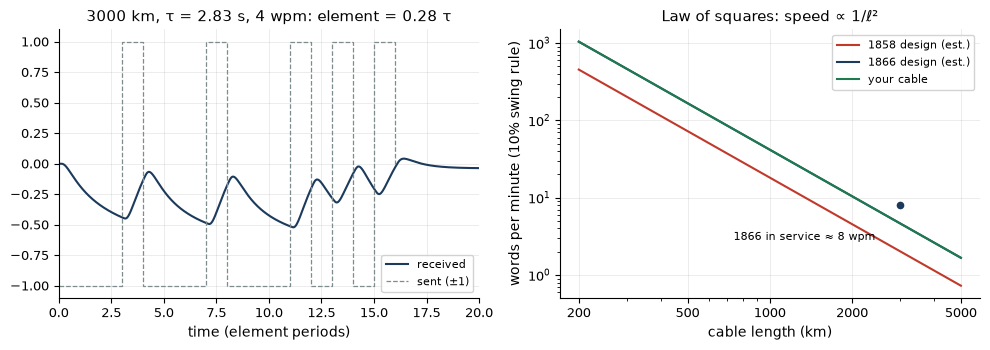

,
time constant τ = RCℓ²,2.83 s
element for a 10% reversal swing (0.24τ),0.68 s
speed at 19 elements per word,4.6 wpm
received swing at your speed (rough),0.28 of sent


In [11]:
def cable_out(bits, T_over_tau, n_t=3000):
    """Far-end voltage of a semi-infinite RC line driven by +-1 elements of duration T (units of tau = RC l^2)."""
    tt = np.linspace(1e-4, T_over_tau * (len(bits) + 6), n_t)
    v = np.zeros_like(tt); prev = 0.0
    for k, b in enumerate(list(bits) + [0]):
        lvl = 0.0 if k == len(bits) else (2.0 * b - 1)
        if lvl != prev:
            tk = tt - k * T_over_tau
            v += (lvl - prev) * np.where(tk > 0, erfc(1 / (2 * np.sqrt(np.maximum(tk, 1e-12)))), 0)
        prev = lvl
    return tt, v

def cable_demo(length_km=3000, r_ohm_km=2.1, c_uf_km=0.15, wpm=4.0):
    tau = r_ohm_km * c_uf_km * 1e-6 * length_km ** 2
    T = 60 / (19 * wpm)                                     # element duration for this speed
    bits = rng.integers(0, 2, 16)
    tt, v = cable_out(bits, T / tau)
    fig, ax = lk.fig("row2", 1, 2)
    ax[0].plot(tt * tau / T, v, color=lk.NAVY, label="received")
    ax[0].step(np.arange(len(bits) + 1), np.r_[2.0 * bits - 1, 0], where="post", color=lk.GRAY, ls="--", lw=0.9, label="sent (±1)")
    ax[0].set_xlabel("time (element periods)"); ax[0].set_xlim(0, len(bits) + 4); ax[0].legend(fontsize=8)
    ax[0].set_title(f"{length_km:g} km, τ = {tau:.2f} s, {wpm:g} wpm: element = {T / tau:.2f} τ")
    L = np.linspace(200, 5000, 200)
    for rc, col, lab in [(5.88 * 0.123e-6, lk.RED, "1858 design (est.)"), (2.10 * 0.150e-6, lk.NAVY, "1866 design (est.)"), (r_ohm_km * c_uf_km * 1e-6, lk.GREEN, "your cable")]:
        ax[1].loglog(L, 60 / (19 * 0.24 * rc * L ** 2), color=col, label=lab)
    ax[1].plot([3000], [8], "o", color=lk.NAVY); ax[1].annotate("1866 in service ≈ 8 wpm", (3000, 8), (-120, -25), textcoords="offset points", fontsize=8)
    ax[1].set_xlabel("cable length (km)"); ax[1].set_ylabel("words per minute (10% swing rule)"); ax[1].legend(fontsize=8)
    ax[1].set_title("Law of squares: speed ∝ 1/ℓ²")
    ax[1].set_xticks([200, 500, 1000, 2000, 5000]); ax[1].set_xticklabels(["200", "500", "1000", "2000", "5000"])
    ax[1].xaxis.set_minor_formatter(plt.NullFormatter())
    lk.show(fig)
    swing = (v[(tt > 4 * T / tau)].max() - v[(tt > 4 * T / tau)].min()) / 2
    lk.table([["time constant τ = RCℓ²", f"{tau:.2f} s"], ["element for a 10% reversal swing (0.24τ)", f"{0.24 * tau:.2f} s"],
              ["speed at 19 elements per word", f"{60 / (19 * 0.24 * tau):.1f} wpm"], ["received swing at your speed (rough)", f"{swing:.2f} of sent"]], ["", ""])

lk.interact(cable_demo, length_km=lk.slider(3000, 200, 6000, 100, "cable length (km)"), r_ohm_km=lk.slider(2.1, 0.5, 8, 0.1, "R (Ω/km)"),
            c_uf_km=lk.slider(0.15, 0.05, 0.3, 0.01, "C (µF/km)"), wpm=lk.slider(4, 0.5, 30, 0.5, "keying speed (wpm)"))

**What you should see.** At 4 wpm on the 1866 cable the received waveform is a slow, smoothed version of the sent pattern, with clear
excursions for every element; at 15 wpm the pulses smear into each other and the swing collapses: intersymbol interference, 150 years
before the term. The table reproduces the chapter: τ ≈ 2.8 s and about 4.6 wpm for 1866. Halve the length and the speed rises
fourfold. The cures were the ones every SerDes still uses: better receivers (Thomson's mirror galvanometer read smaller swings) and
pre-emphasis (curb signalling).

### Try it yourself 3.1
By the 10%-swing rule, how many words per minute could a 1500 km cable of the 1866 design carry?

In [13]:
answer_3_1 = None
lk.check("3.1 wpm on 1500 km (1866 design)", answer_3_1, 60 / (19 * 0.24 * 2.1 * 0.15e-6 * 1500 ** 2), rtol=0.03)

[TODO] 3.1 wpm on 1500 km (1866 design): not attempted yet: replace the None with your answer

## 4. Analog repeaters versus regenerators

An analog repeater amplifies signal and noise alike, so the noise of $N$ identical spans adds: the end-to-end SNR is the per-span SNR
minus $10\log_{10}N$. A digital regenerator decides each symbol and re-sends a clean one, so only the *errors* accumulate, and they grow
only linearly: $P_e \approx N\,Q(\sqrt{\mathrm{SNR}})$. Chapter 1's example: a 2000 km coaxial route with 1000 spans needs 70 dB per span for
40 dB end to end, while a binary regenerator chain at 17 dB per span delivers a total error probability of about $7\times10^{-10}$.

### Interactive: spans and per-span SNR

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

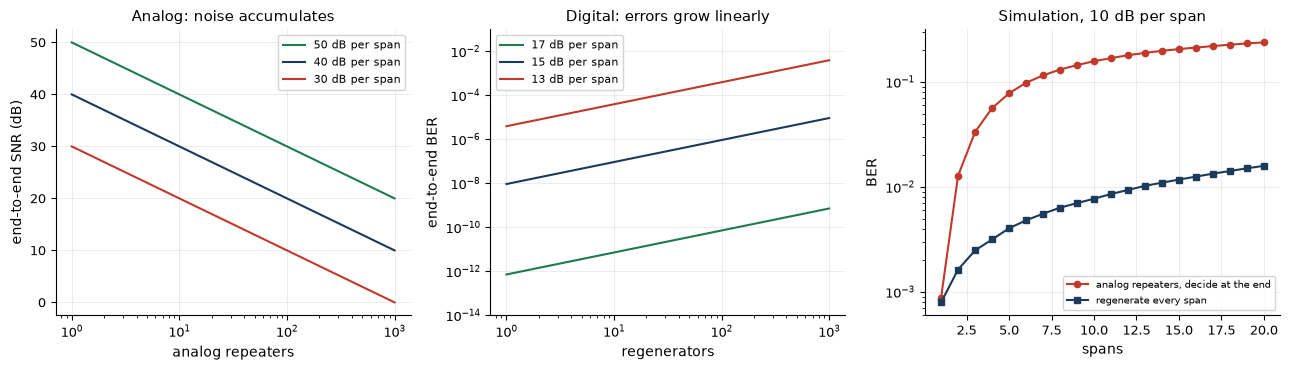

,
analog: per-span SNR for 40 dB over 1000 spans,70 dB
digital: BER per span at 17 dB,7.2e-13
digital: end-to-end over 1000 spans,7.2e-10


In [15]:
def repeater_demo(n_spans=1000, snr_db=17.0, sim_spans=20):
    N = np.unique(np.round(np.logspace(0, 3, 60)).astype(int))
    fig, ax = lk.fig((13, 3.8), 1, 3)
    for s_, col in [(50, lk.GREEN), (40, lk.NAVY), (30, lk.RED)]:
        ax[0].semilogx(N, s_ - 10 * np.log10(N), color=col, label=f"{s_} dB per span")
    ax[0].set_xlabel("analog repeaters"); ax[0].set_ylabel("end-to-end SNR (dB)"); ax[0].legend(fontsize=8); ax[0].set_title("Analog: noise accumulates")
    for s_, col in [(17, lk.GREEN), (15, lk.NAVY), (13, lk.RED)]:
        ax[1].loglog(N, N * Qf(np.sqrt(lk.undb(s_))), color=col, label=f"{s_} dB per span")
    ax[1].set_ylim(1e-14, 1e-1); ax[1].set_xlabel("regenerators"); ax[1].set_ylabel("end-to-end BER"); ax[1].legend(fontsize=8); ax[1].set_title("Digital: errors grow linearly")
    # simulate both chains at a low per-span SNR so that errors are visible
    r = np.random.default_rng(1)
    bits = r.integers(0, 2, 200_000); a = 2.0 * bits - 1
    sig = np.sqrt(1 / lk.undb(snr_db - 7))                 # a deliberately noisy span, 7 dB worse, to see errors
    x_an = a.copy(); x_dg = a.copy(); ber_an, ber_dg = [], []
    for k in range(sim_spans):
        x_an = x_an + sig * r.standard_normal(len(a))
        x_dg = np.sign(x_dg + sig * r.standard_normal(len(a)))
        ber_an.append(np.mean((x_an > 0) != bits)); ber_dg.append(np.mean((x_dg > 0) != bits))
    ax[2].semilogy(np.arange(1, sim_spans + 1), np.maximum(ber_an, 1e-6), "o-", color=lk.RED, label="analog repeaters, decide at the end")
    ax[2].semilogy(np.arange(1, sim_spans + 1), np.maximum(ber_dg, 1e-6), "s-", color=lk.NAVY, label="regenerate every span")
    ax[2].set_xlabel("spans"); ax[2].set_ylabel("BER"); ax[2].legend(fontsize=7.5); ax[2].set_title(f"Simulation, {snr_db - 7:g} dB per span")
    lk.show(fig)
    lk.table([[f"analog: per-span SNR for 40 dB over {n_spans} spans", f"{40 + 10 * np.log10(n_spans):.0f} dB"],
              [f"digital: BER per span at {snr_db:g} dB", f"{Qf(np.sqrt(lk.undb(snr_db))):.1e}"],
              [f"digital: end-to-end over {n_spans} spans", f"{n_spans * Qf(np.sqrt(lk.undb(snr_db))):.1e}"]], ["", ""])

lk.interact(repeater_demo, n_spans=lk.choice([10, 100, 1000, 10000], 1000, "spans"), snr_db=lk.slider(17, 10, 22, 0.5, "per-span SNR (dB)"),
            sim_spans=lk.islider(20, 5, 50, 1, "simulated spans"))

**What you should see.** The analog chain needs 70 dB per span for 40 dB end to end; the digital chain at 17 dB per span has a per-span
error probability of about $7\times10^{-13}$ and $7\times10^{-10}$ end to end, the chapter's numbers: some 50 dB less SNR per span. In the
simulation, the analog chain's BER climbs steadily with every span as noise piles up, while the regenerated chain's grows only in
proportion to the number of spans, starting from a far lower value.

## 5. Semaphores and telephone lines: rates and capacity

Two bookends from Chapter 1. The Chappe semaphore (Paris–Lille, about 15 stations) sent one of 92 signs every 30 s: Hartley's
$\log_2 92 = 6.52$ bits per sign, 0.22 bit/s, with about 7.5 minutes of latency. A telephone line of 3.1 kHz at 35 dB SNR has a Shannon
capacity of about 36 kb/s, and the V.34 modem reached 33.6 kb/s.

Chapter 1 numbers,
semaphore: bits per sign log2(92),6.52
semaphore: raw rate (one sign per 30 s),0.22 bit/s
semaphore: latency over 15 stations at 30 s each,7.5 min
"telephone line, 3.1 kHz at 30 dB",30.9 kb/s
"telephone line, 3.1 kHz at 35 dB",36.0 kb/s
"telephone line, 3.1 kHz at 40 dB",41.2 kb/s
V.34 (1994–96),33.6 kb/s


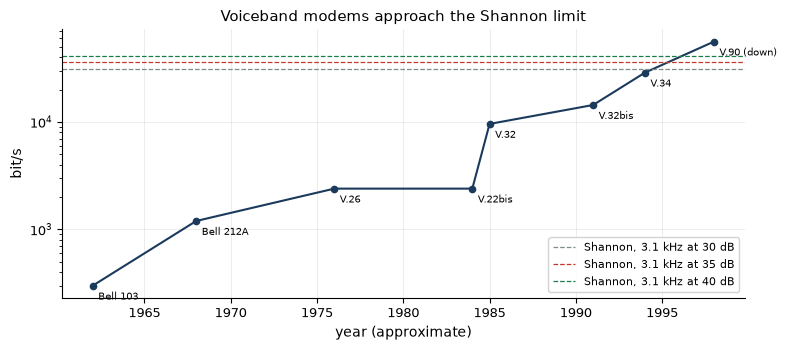

In [17]:
snrs = np.array([30, 35, 40])
lk.table([["semaphore: bits per sign log2(92)", f"{np.log2(92):.2f}"], ["semaphore: raw rate (one sign per 30 s)", f"{np.log2(92) / 30:.2f} bit/s"],
          ["semaphore: latency over 15 stations at 30 s each", f"{15 * 30 / 60:.1f} min"]] +
         [[f"telephone line, 3.1 kHz at {s_} dB", f"{3100 * np.log2(1 + lk.undb(s_)) / 1e3:.1f} kb/s"] for s_ in snrs] +
         [["V.34 (1994–96)", "33.6 kb/s"]], ["Chapter 1 numbers", ""])
years = [1962, 1968, 1976, 1984, 1985, 1991, 1994, 1998]
rates = [300, 1200, 2400, 2400, 9600, 14400, 28800, 56000]
names = ["Bell 103", "Bell 212A", "V.26", "V.22bis", "V.32", "V.32bis", "V.34", "V.90 (down)"]
f, ax = lk.fig((8, 3.6))
ax.semilogy(years, rates, "o-", color=lk.NAVY)
for y, r_, n in zip(years, rates, names):
    ax.annotate(n, (y, r_), (4, -10), textcoords="offset points", fontsize=7.5)
for s_, col in zip(snrs, [lk.GRAY, lk.RED, lk.GREEN]):
    ax.axhline(3100 * np.log2(1 + lk.undb(s_)), color=col, ls="--", lw=0.9, label=f"Shannon, 3.1 kHz at {s_} dB")
ax.set_xlabel("year (approximate)"); ax.set_ylabel("bit/s"); ax.legend(fontsize=8); ax.set_title("Voiceband modems approach the Shannon limit")
lk.show(f)

**What you should see.** 6.52 bits per sign and 0.22 bit/s for the semaphore; 31, 36 and 41 kb/s of capacity for the telephone line at
30, 35 and 40 dB. Modems climbed towards the limit for thirty years; V.90's 56 kb/s downstream did not break it, because that path is a
64 kb/s PCM stream with only one analog loop to cross.

### Try it yourself 5.1
What is the Shannon capacity (kb/s) of a 3.1 kHz line at 25 dB SNR?

In [19]:
answer_5_1 = None
lk.check("5.1 capacity at 25 dB (kb/s)", answer_5_1, 3100 * np.log2(1 + lk.undb(25)) / 1e3, atol=0.2)

[TODO] 5.1 capacity at 25 dB (kb/s): not attempted yet: replace the None with your answer

## Key takeaways
* Morse code is a variable-length source code with timing constraints; on Shannon's telegraph channel it is about 85% efficient.
* Hard on/off keying splatters; shaped edges contain the spectrum: the first lesson in pulse shaping.
* A long cable is a diffusion line: delay and pulse spreading grow as the square of the length; this is intersymbol interference.
* Analog repeaters accumulate noise; regenerators accumulate only errors. That is why every system became digital.
* Capacity, not Hartley's symbol count, is the right measure of a channel, and engineers reached it within a few dB.

## Going further (hardware: USRP B200 / GNU Radio)
* Generate a keyed carrier with the envelope of Section 1 and transmit it from the B200 at a low level into a 30 dB attenuator; capture
  it with `gnuradio/gr01_spectrum_iq_capture.py` and compare the measured key clicks for hard and shaped keying.
* Listen to real CW (Morse) signals on the amateur bands (e.g. 7.0–7.04 MHz needs an upconverter; 144.05 MHz is within the B200's range)
  and decode them by thresholding the envelope.

## Exercises
1. **(Warm-up)** Show that PARIS, with its word gap, is 50 units long.
2. **(Core)** Replace English by French or German letter frequencies in Section 2 and recompute Morse's efficiency.
3. **(Core)** Add curb signalling to Section 3 (each element followed by a short opposite pulse) and find the speed gain at a 10% swing.
4. **(Stretch)** Compute Shannon's telegraph capacity for a different timing (e.g. dash = 2 dots) and design the best Morse-like code for it.

In [21]:
lk.summary()

[good] Lab 34 finished in 2.0 s. Self-checks: 0 passed, 0 failed, 4 still to do.